# Feature engineering (preparación de variables)

## Definición

La ingeniería de características ("feature engineering") es el proceso de transformar datos brutos en variables (o "features") más adecuadas para un modelo de aprendizaje automático. Incluye la selección, manipulación y creación de features para mejorar el rendimiento y la precisión del modelo, y se basa en la combinación de análisis de datos, conocimiento del dominio y heurísticas.

### Proceso de ingeniería de características

- **Transformación**: Modificar los datos existentes para que el modelo pueda procesarlos mejor. Esto puede incluir escalar o normalizar datos numéricos, o codificar datos categóricos (como texto o imágenes).
- **Enriquecimiento**: Crear nuevas características a partir de las existentes. Esto se puede hacer combinando varias columnas, aplicando funciones matemáticas o extrayendo información más específica.
- **Selección**: Elegir las características más relevantes para el problema específico. Las características poco útiles o redundantes se pueden eliminar para mejorar la eficiencia del modelo.

## Ejemplos
- **Creación de nuevas características**: Combinar la altura y el peso de una persona para calcular el índice de masa corporal (IMC), que es una nueva característica más predictiva que la altura o el peso por sí solos.
- **Manejo de datos no numéricos**: Convertir el texto en representaciones numéricas usando técnicas como TF-IDF o "word embeddings" (por ejemplo, Word2Vec) para que el modelo pueda procesarlo.
- **Agregación de datos**: Agrupar datos por tiempo o por entidad para crear resúmenes que contengan información valiosa. Por ejemplo, calcular la venta promedio de un producto en el último mes.
- **Escalado y normalización**: Ajustar el rango de las variables numéricas para que todas tengan un valor comparable, lo cual es crucial para muchos algoritmos.

## Técnicas

- Manejo de valores faltantes, (eliminar o encontrar un valor adecuado - imputación)
- Manejo de valores atípicos, eliminarlos o preservarlos.
- Binning, agrupar valores en clases típicamente para convertir variables contínuas en discretas.
- Transformación logaritmica, para lidiar con distribuciones muy asimétricas
- One-hot enconding, convertir variables nominales en 0s y 1s
- Separación de valor (Feature Split). Por ejemplo,  convertir nombre completo en nombre y apellido.
- __[Ajuste de escala](https://en.wikipedia.org/wiki/Feature_scaling)__., para ubicar variables en rangos adecuados.


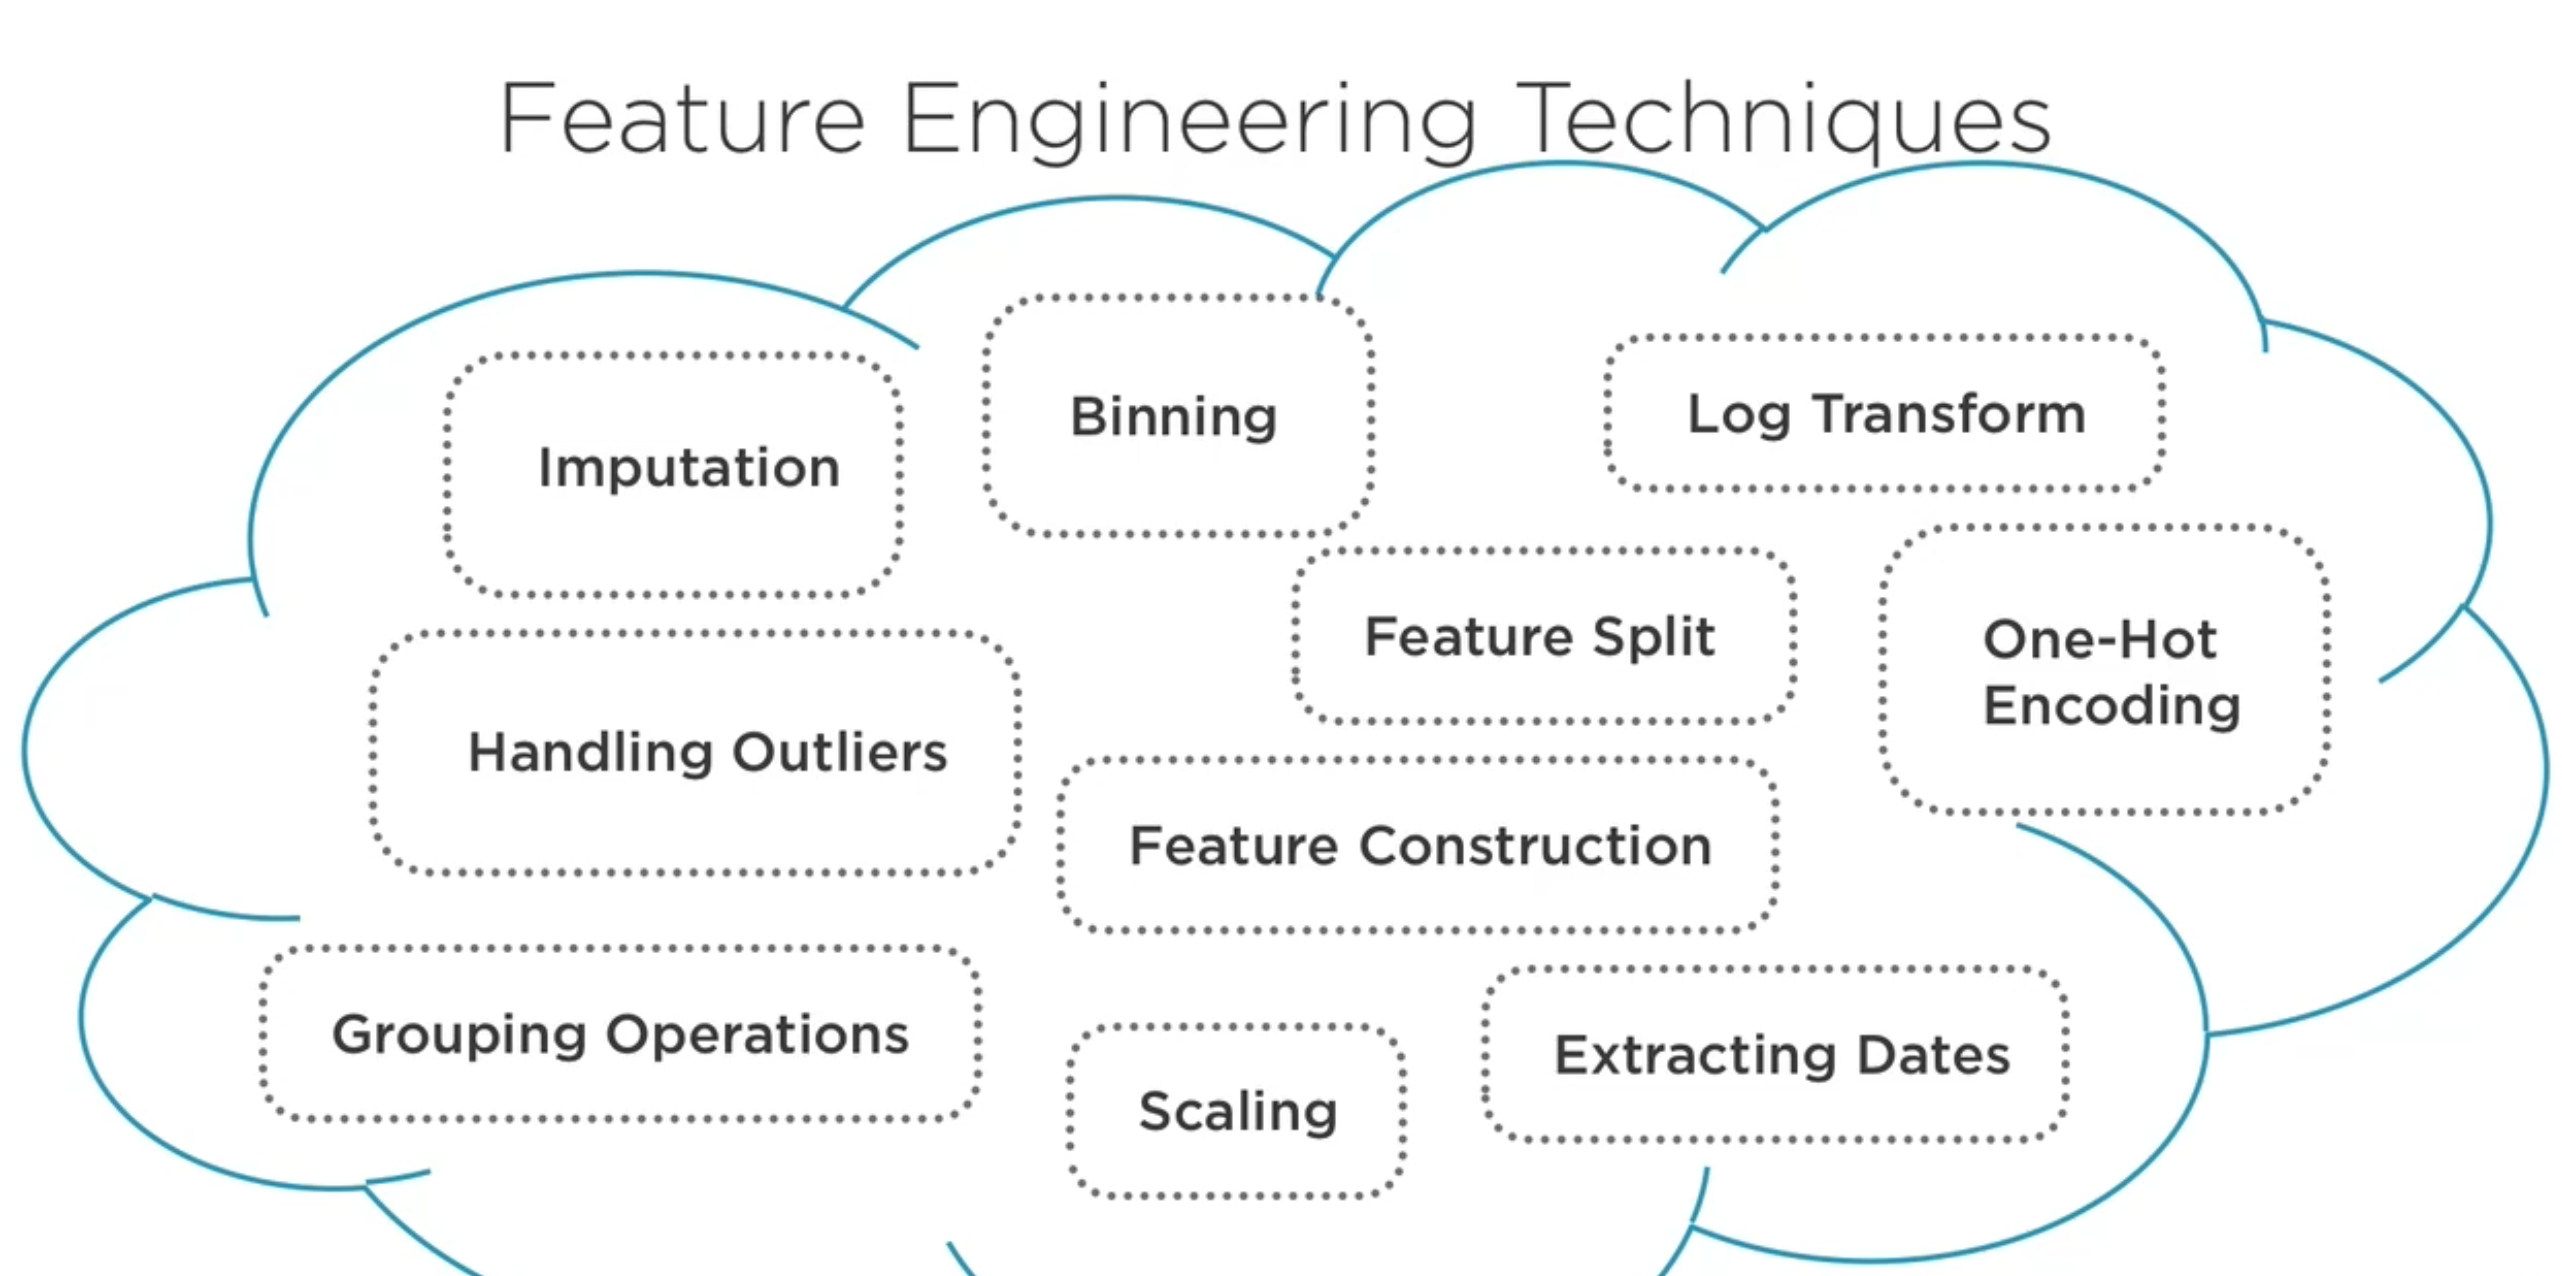

In [2]:
import polars as pl

In [4]:
df = pl.read_csv("diabetes.csv")
df

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0
2,122,70,27,0,36.8,0.34,27,0
5,121,72,23,112,26.2,0.245,30,0


In [ ]:
# df_p.with_columns(
#    pl.Series(range(df_p.height)).alias('Index')
# )

## Valores faltantes

In [ ]:
# Actualizamos la fila en el índice 3 con un valor nulo (null)
# Simular el dato faltante (sabemos que era 21)
df = df.with_columns(
    pl.when(pl.Series(range(df.height)) == 3)
    .then(pl.lit(None))
    .otherwise(pl.col('Age'))
    .alias('Age')
)

df.head()

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,null,0
0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# 'count' es muy útil para detectar valores faltantes
df.describe()

statistic,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",768.0,768.0,768.0,768.0,768.0,768.0,768.0,767.0,768.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
"""mean""",3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.256845,0.348958
"""std""",3.369578,31.972618,19.355807,15.952218,115.244002,7.88416,0.331329,11.75958,0.476951
"""min""",0.0,0.0,0.0,0.0,0.0,0.0,0.078,21.0,0.0
"""25%""",1.0,99.0,62.0,0.0,0.0,27.3,0.244,24.0,0.0
"""50%""",3.0,117.0,72.0,23.0,32.0,32.0,0.374,29.0,0.0
"""75%""",6.0,140.0,80.0,32.0,127.0,36.6,0.626,41.0,1.0
"""max""",17.0,199.0,122.0,99.0,846.0,67.1,2.42,81.0,1.0


In [ ]:
df.filter(pl.col('Age').is_null())

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
1,89,66,23,94,28.1,0.167,null,0


**Opción 1: Eliminación de valores faltantes**

In [ ]:
df.drop_nulls(subset=["Age"])

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
0,137,40,35,168,43.1,2.288,33,1
5,116,74,0,0,25.6,0.201,30,0
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0
2,122,70,27,0,36.8,0.34,27,0
5,121,72,23,112,26.2,0.245,30,0


**Opción 2: Asignación de valores (imputación)**

Estrategias comunes

- Variables numéricas - agrupar por una variable discreta correlacionada a la variable con el valor faltante; agrupar por la variable correlacionada y emplear una tendencias central no sensible a los valores atípicos (la mediana por ejemplo)

- Variables categóricas - encontrar observaciones/ejemplos similares al caso con el valor faltante; aplicar análisis exploratorio para **encontrar evidencias que permitan respaldar** la selección de valor categórico empleado como reemplazo.

**Ejemplo variable numérica (edad)**

In [ ]:
#Usar un valor constante casi nunca es buena idea!
# df.with_columns(
#     pl.col("Age").fill_null(0)
# )

In [ ]:
#Usar la media/mediana de todos los casos pocas veces es buena idea! Es recomendable emplear este valor únicamente
#como una línea base que nos permite comparar los resultados obtenidos con otras estrategias.
df.with_columns(
    pl.col("Age").fill_null(pl.col("Age").mean().round())
)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,f64,i64
6,148,72,35,0,33.6,0.627,50.0,1
1,85,66,29,0,26.6,0.351,31.0,0
8,183,64,0,0,23.3,0.672,32.0,1
1,89,66,23,94,28.1,0.167,33.0,0
0,137,40,35,168,43.1,2.288,33.0,1
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63.0,0
2,122,70,27,0,36.8,0.34,27.0,0
5,121,72,23,112,26.2,0.245,30.0,0


In [ ]:
# La edad faltante era 21
# Qué variable podríamos usar para obtener una mejor aproximación a la edad?
# Nos serán más útiles las variables con mayor o menor correlación con la edad?
# Muchas veces es suficiente apoyarse en el sentido común junto con el conocimiento de los datos y conocimiento del dominio
# Por ejemplo, si falta el apellido paterno en un registro: podriamos ubicar a los hermanos y usar su apellido paterno

In [ ]:
por_embarazos = df.group_by('Pregnancies')
por_embarazos

In [ ]:
# Se recomienda emplear la métrica de tendencia central que sea menos afectada por valores atípicos
# cuál es?

In [ ]:
por_embarazos.agg(
    pl.col("Age").median().alias("median_age").round()
    , pl.col("Age").mean().alias("average_age").round()
).sort("Pregnancies")

Pregnancies,median_age,average_age
i64,f64,f64
0,25.0,28.0
1,24.0,27.0
2,25.0,27.0
3,27.0,29.0
4,30.0,33.0
…,…,…
12,46.0,47.0
13,44.0,44.0
14,42.0,42.0


<Axes: title={'center': 'Age'}, xlabel='Pregnancies'>

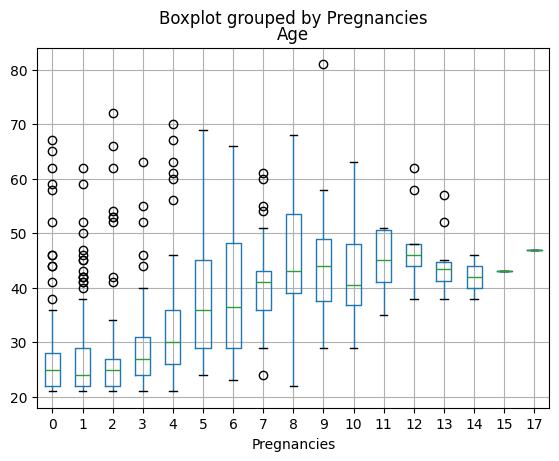

In [ ]:
#Como siempre, se recomienda complementar el análisis con gráficos
#El gráfico de caja muestra la media o mediana?
df_pandas = df.to_pandas()
df_pandas[df_pandas['Age'].notnull()].boxplot('Age','Pregnancies')

**Imputacion aplicando promedio grupal**

Una aplicación de varios aspectos de Polars cubiertos en notebooks previos

In [ ]:
df.with_columns(
  pl.col('Age').mean().over('Pregnancies').round().alias("avg_age")
).head()

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome,avg_age
i64,i64,i64,i64,i64,f64,f64,i64,i64,f64
6,148,72,35,0,33.6,0.627,50,1,39.0
1,85,66,29,0,26.6,0.351,31,0,27.0
8,183,64,0,0,23.3,0.672,32,1,45.0
1,89,66,23,94,28.1,0.167,null,0,27.0
0,137,40,35,168,43.1,2.288,33,1,28.0


In [ ]:
df.with_columns(
    pl.col('Age').fill_null(
        pl.col('Age').mean().over('Pregnancies').round()
    )
).head()

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,f64,i64
6,148,72,35,0,33.6,0.627,50.0,1
1,85,66,29,0,26.6,0.351,31.0,0
8,183,64,0,0,23.3,0.672,32.0,1
1,89,66,23,94,28.1,0.167,27.0,0
0,137,40,35,168,43.1,2.288,33.0,1


## Valores atípicos

- Eliminar: Si claramente son datos erróneos.

- Reemplazar: Puede reemplazar los valores atípicos con un valor estadístico como el máximo o el mínimo de la columna.

- Transformaciones: Aplique transformaciones como el logaritmo o la raíz cuadrada si el modelo es sensible a valores atípicos.

- Modelos robustos: Utilice modelos menos sensibles a los valores atípicos.

In [ ]:
import polars as pl

df = pl.read_csv("diabetes.csv")

<Axes: >

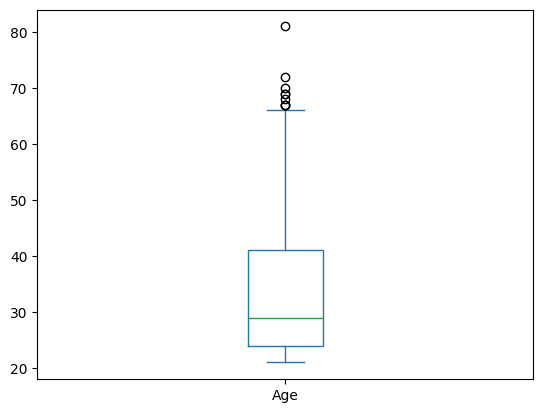

In [ ]:
df.to_pandas()['Age'].plot.box()

In [ ]:
quartiles = df.select([
    pl.col('Age').quantile(0.25).alias('Q1'),
    pl.col('Age').quantile(0.75).alias('Q3')
])
quartiles

Q1,Q3
f64,f64
24.0,41.0


In [ ]:
q3 = quartiles.get_column('Q3')[0]
q1 = quartiles.get_column('Q1')[0]

IQR = q3 - q1
IQR

17.0

In [ ]:
df.filter(
    pl.col("Age").gt(q3 + 1.5 * IQR)
    | pl.col("Age").lt(q1 - 1.5 * IQR)
)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
5,132,80,0,0,26.8,0.186,69,0
4,146,78,0,0,38.5,0.52,67,1
2,119,0,0,0,19.6,0.832,72,0
9,134,74,33,60,25.9,0.46,81,0
8,194,80,0,0,26.1,0.551,67,0
0,57,60,0,0,21.7,0.735,67,0
4,145,82,18,0,32.5,0.235,70,1
8,91,82,0,0,35.6,0.587,68,0
5,136,82,0,0,0.0,0.64,69,0


In [ ]:
df.remove(
    pl.col("Age").gt(q3 + 1.5 * IQR)
    | pl.col("Age").lt(q1 - 1.5 * IQR)
)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0
2,122,70,27,0,36.8,0.34,27,0
5,121,72,23,112,26.2,0.245,30,0


## Binning

También conocida como discretización, consiste en dividir una variable continua en intervalos o "contenedores". Al agrupar los valores en rangos discretos, podemos simplificar la entrada del modelo y capturar relaciones no lineales entre las características y la variable objetivo

In [ ]:
import polars as pl

df = pl.read_csv("diabetes.csv")

In [ ]:
df = df.with_columns(
    pl.col("Age").map_elements(lambda age: 1 if age <= 35 else 0).alias("YoungAdult")
)
df.head()

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome,YoungAdult
i64,i64,i64,i64,i64,f64,f64,i64,i64,i64
6,148,72,35,0,33.6,0.627,50,1,0
1,85,66,29,0,26.6,0.351,31,0,1
8,183,64,0,0,23.3,0.672,32,1,1
1,89,66,23,94,28.1,0.167,21,0,1
0,137,40,35,168,43.1,2.288,33,1,1


In [ ]:
df.filter(pl.col('YoungAdult') == 0)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome,YoungAdult
i64,i64,i64,i64,i64,f64,f64,i64,i64,i64
6,148,72,35,0,33.6,0.627,50,1,0
2,197,70,45,543,30.5,0.158,53,1,0
8,125,96,0,0,0.0,0.232,54,1,0
10,139,80,0,0,27.1,1.441,57,0,0
1,189,60,23,846,30.1,0.398,59,1,0
…,…,…,…,…,…,…,…,…,…
0,123,72,0,0,36.3,0.258,52,1,0
6,190,92,0,0,35.5,0.278,66,1,0
9,170,74,31,0,44.0,0.403,43,1,0


In [ ]:
df.filter(pl.col('YoungAdult') == 1)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome,YoungAdult
i64,i64,i64,i64,i64,f64,f64,i64,i64,i64
1,85,66,29,0,26.6,0.351,31,0,1
8,183,64,0,0,23.3,0.672,32,1,1
1,89,66,23,94,28.1,0.167,21,0,1
0,137,40,35,168,43.1,2.288,33,1,1
5,116,74,0,0,25.6,0.201,30,0,1
…,…,…,…,…,…,…,…,…,…
2,88,58,26,16,28.4,0.766,22,0,1
9,89,62,0,0,22.5,0.142,33,0,1
2,122,70,27,0,36.8,0.34,27,0,1


### Métodos `cut` y `qcut`

Estas funciones son fundamentales para la **discretización** de datos:

1.  **`cut` (Basado en valores):** Divide el rango de los datos en intervalos de igual ancho o en límites definidos manualmente. Es útil cuando los límites tienen un significado de negocio (ej. rangos de edad).
2.  **`qcut` (Basado en muestras/cuantiles):** Divide los datos de forma que cada intervalo tenga aproximadamente el mismo número de observaciones. Es ideal para comparar el rendimiento de diferentes grupos (ej. el 25% que más gana vs el 25% que menos gana).

In [ ]:
import polars as pl

df = pl.read_csv("diabetes.csv")
df

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0
2,122,70,27,0,36.8,0.34,27,0
5,121,72,23,112,26.2,0.245,30,0


In [ ]:
df.with_columns(
    pl.col("BloodPressure").qcut(
        quantiles=4,
        labels=['very_low','low','high','very_high']
    ).alias("BloodPressureGrade")
)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome,BloodPressureGrade
i64,i64,i64,i64,i64,f64,f64,i64,i64,cat
6,148,72,35,0,33.6,0.627,50,1,"""low"""
1,85,66,29,0,26.6,0.351,31,0,"""low"""
8,183,64,0,0,23.3,0.672,32,1,"""low"""
1,89,66,23,94,28.1,0.167,21,0,"""low"""
0,137,40,35,168,43.1,2.288,33,1,"""very_low"""
…,…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0,"""high"""
2,122,70,27,0,36.8,0.34,27,0,"""low"""
5,121,72,23,112,26.2,0.245,30,0,"""low"""


In [ ]:
df.with_columns(
    pl.col("Age").cut(
        breaks=[18, 35, 60],
        labels=["Child/Teenager", "Young Adult", "Adult", "Senior"]
    ).alias("Age_Category")
)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome,Age_Category
i64,i64,i64,i64,i64,f64,f64,i64,i64,cat
6,148,72,35,0,33.6,0.627,50,1,"""Adult"""
1,85,66,29,0,26.6,0.351,31,0,"""Young Adult"""
8,183,64,0,0,23.3,0.672,32,1,"""Young Adult"""
1,89,66,23,94,28.1,0.167,21,0,"""Young Adult"""
0,137,40,35,168,43.1,2.288,33,1,"""Young Adult"""
…,…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0,"""Senior"""
2,122,70,27,0,36.8,0.34,27,0,"""Young Adult"""
5,121,72,23,112,26.2,0.245,30,0,"""Young Adult"""


## Transformación logarítmica

### Reducir la asimetría (skewness)
La transformación logarítmica (por ejemplo, aplicar `log(x)`) se usa para reducir la asimetría (skewness) y acercar los datos a una distribución más normal, lo cual facilita el trabajo de muchos algoritmos estadísticos y de machine learning.

### Reducir la influencia de outliers
Los valores extremos (outliers) en una escala amplia pueden distorsionar el ajuste del modelo.
La transformación logarítmica comprime los valores grandes y expande los pequeños, reduciendo el impacto de los extremos.

### Mejorar la estabilidad numérica
Algunos algoritmos (como redes neuronales o modelos de regresión regularizados) se comportan mejor cuando las variables (features) tienen magnitudes similares.
El log ayuda a controlar el rango numérico y evitar problemas de desbordamiento o gradientes inestables.

### Consideraciones prácticas

Solo se puede aplicar logaritmo a valores positivos.
Si tienes ceros o negativos, usa:

- log1p(x) → calcula log(1 + x)
- O desplaza los valores: log(x + c) con c > 0


**Recuerde que log(0) = infinito**

In [5]:
df.select(pl.col('Pregnancies').skew())

Pregnancies
f64
0.899912


<Axes: ylabel='Density'>

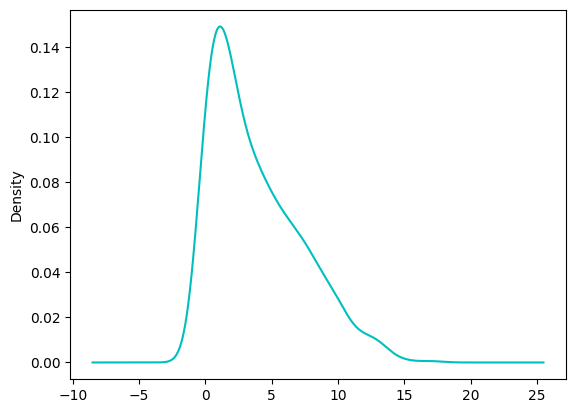

In [6]:
df.to_pandas()['Pregnancies'].plot.density(color='c')

In [11]:
df.with_columns(
    pl.col("Pregnancies").log1p().alias("Pregnancies_log1p")
).select(["Pregnancies", "Pregnancies_log1p"]).head()

Pregnancies,Pregnancies_log1p
i64,f64
6,1.94591
1,0.693147
8,2.197225
1,0.693147
0,0.0


<Axes: ylabel='Density'>

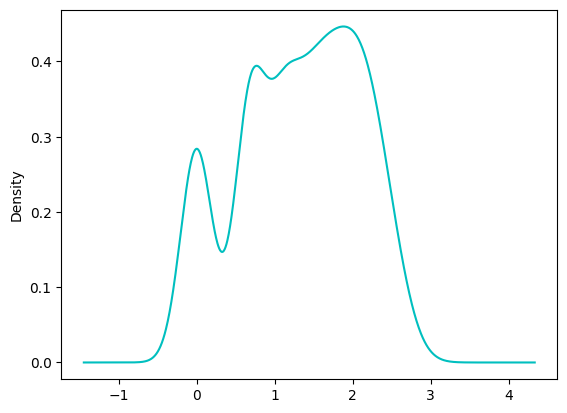

In [8]:
df.with_columns(
    pl.col("Pregnancies").log1p().alias("Pregnancies_log1p")
).to_pandas()['Pregnancies_log1p'].plot.density(color='c')

## One-hot encoding

### Cuando tienes variables categóricas nominales (sin orden natural)

Ejemplo clásico: color, país, marca, género, tipo de producto, etc.
Cuándo aplicarlo:

- Cuando el modelo no puede manejar texto ni categorías directamente (por ejemplo, regresión lineal, redes neuronales, SVM, k-means).

- Cuando las categorías no tienen un orden intrínseco (no hay "mayor" o "menor").

## Cuando se busca evitar interpretaciones erróneas

Si usaras Label Encoding (asignar 0, 1, 2, … a las categorías), el modelo podría asumir una relación ordinal falsa:

Ejemplo:

Si rojo=0, azul=1, verde=2,

el modelo puede creer que `verde > azul > rojo`, lo cual no tiene sentido.

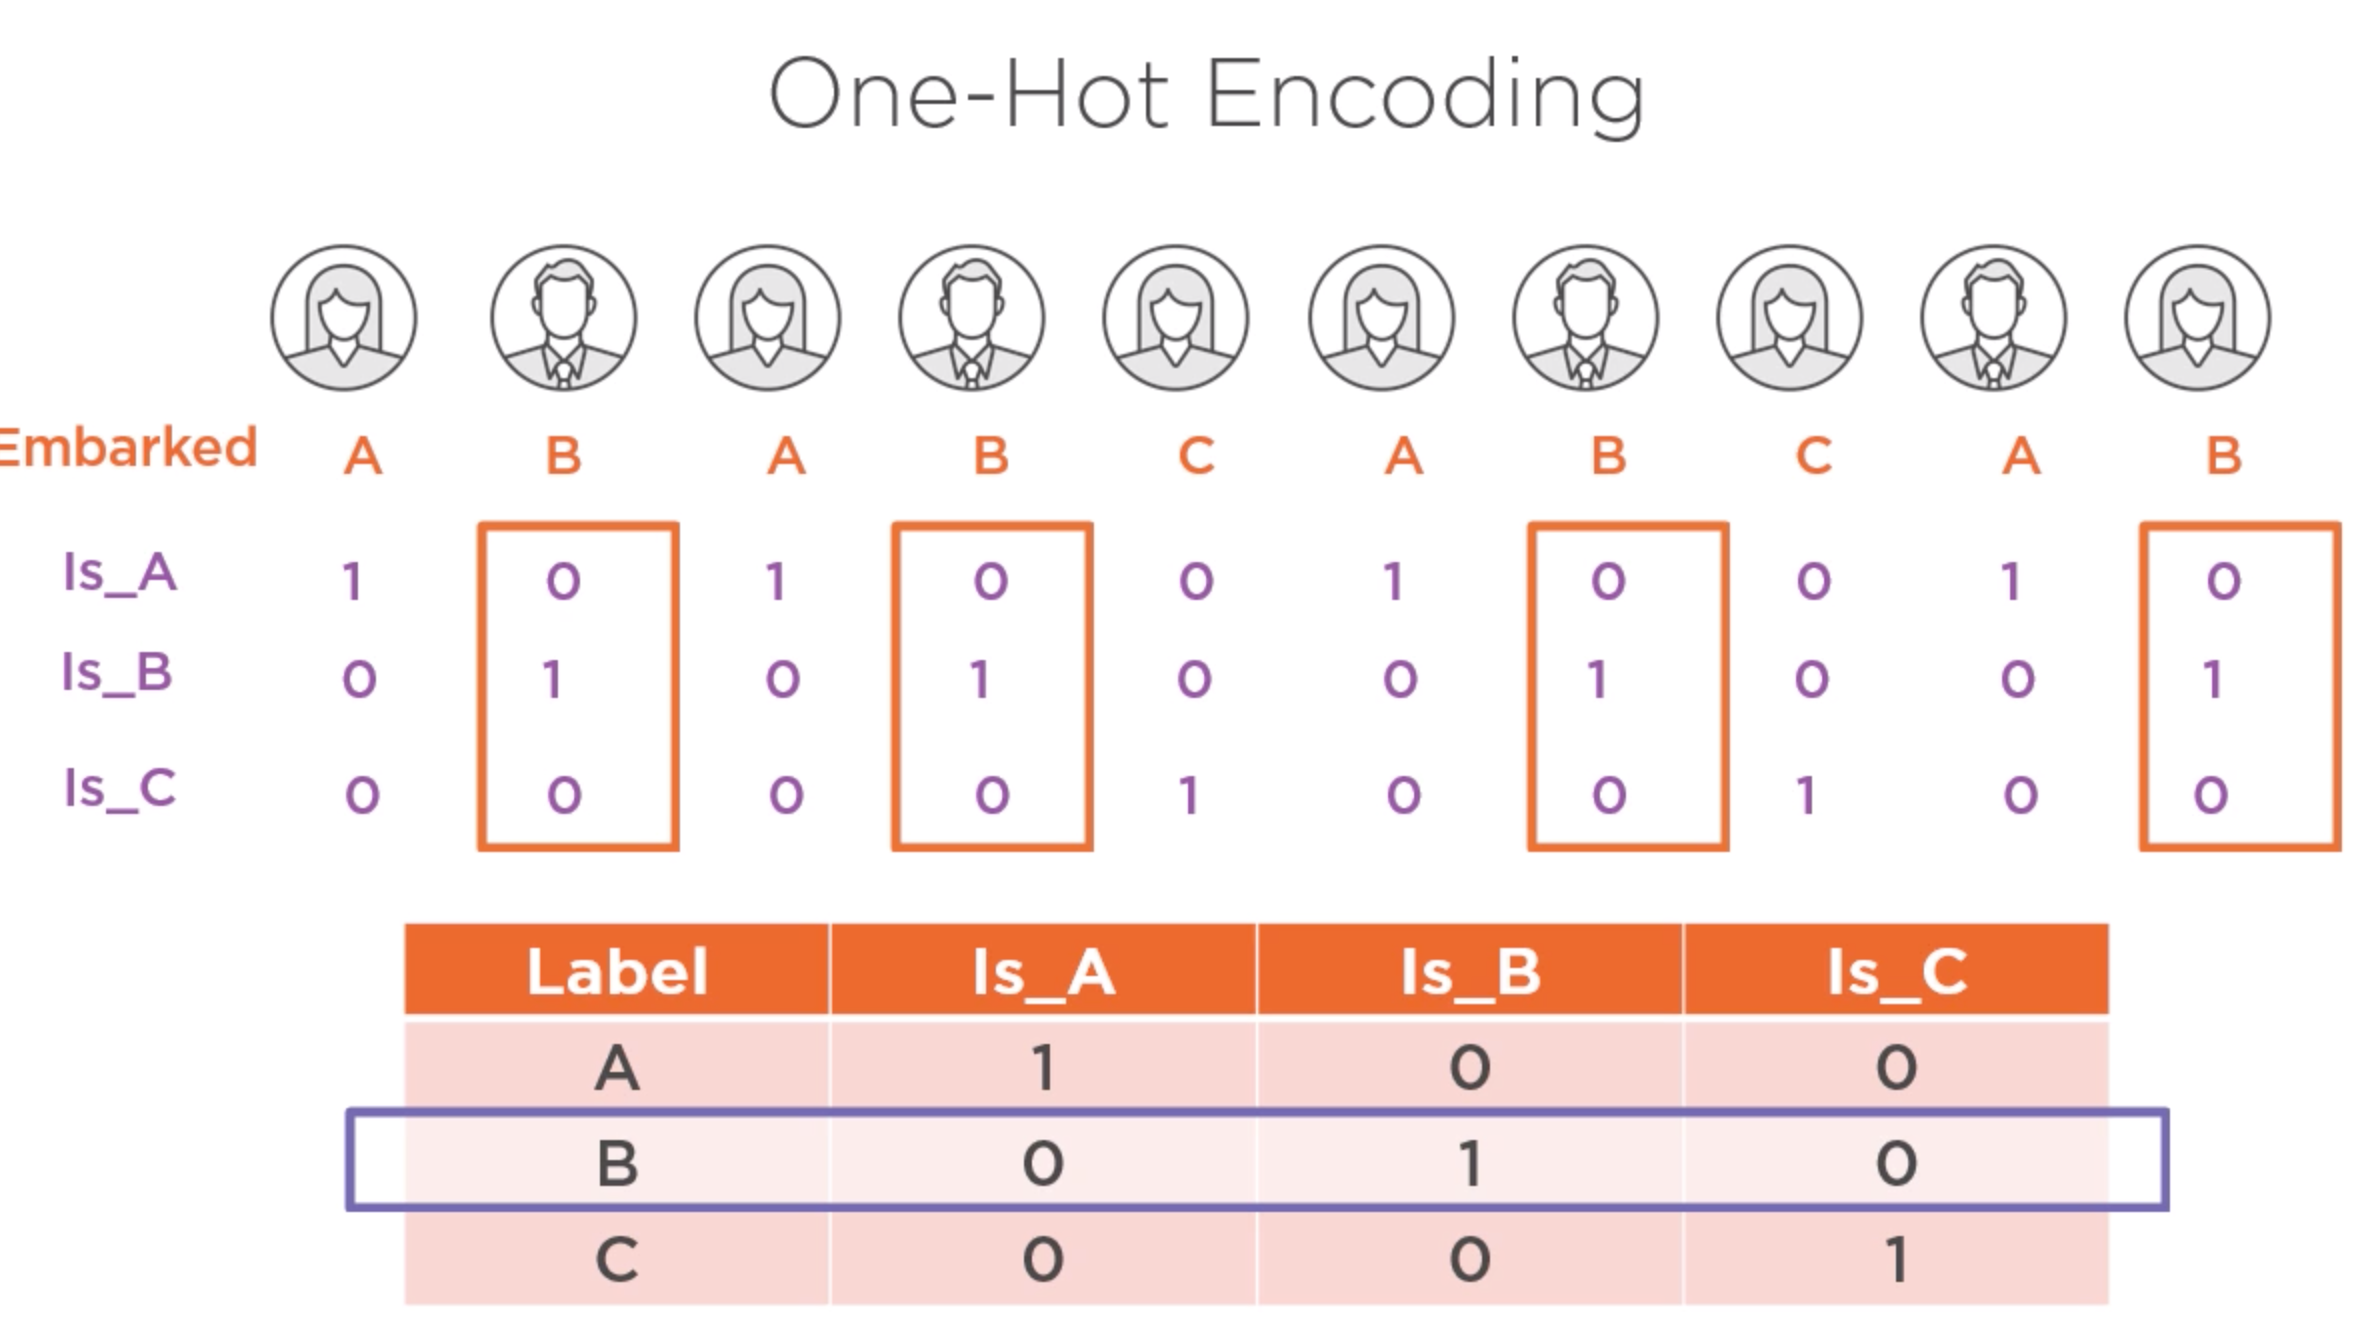

### One-hot encoding en Polars
Podemos usar el método `to_dummies` para convertir variables categóricas en columnas binarias.

In [13]:
import polars as pl

df = pl.read_csv("diabetes.csv")

In [14]:
# Creamos una columna categórica para el ejemplo
df = df.with_columns(
    pl.col("Age").cut(
        breaks=[35, 55],
        labels=["young", "middle", "old"]
    ).alias("AgeCategory")
)
df

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome,AgeCategory
i64,i64,i64,i64,i64,f64,f64,i64,i64,cat
6,148,72,35,0,33.6,0.627,50,1,"""middle"""
1,85,66,29,0,26.6,0.351,31,0,"""young"""
8,183,64,0,0,23.3,0.672,32,1,"""young"""
1,89,66,23,94,28.1,0.167,21,0,"""young"""
0,137,40,35,168,43.1,2.288,33,1,"""young"""
…,…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0,"""old"""
2,122,70,27,0,36.8,0.34,27,0,"""young"""
5,121,72,23,112,26.2,0.245,30,0,"""young"""


In [15]:
# Aplicamos one-hot encoding a la columna 'AgeCategory'
df.to_dummies("AgeCategory").head()

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome,AgeCategory_middle,AgeCategory_old,AgeCategory_young
i64,i64,i64,i64,i64,f64,f64,i64,i64,u8,u8,u8
6,148,72,35,0,33.6,0.627,50,1,1,0,0
1,85,66,29,0,26.6,0.351,31,0,0,0,1
8,183,64,0,0,23.3,0.672,32,1,0,0,1
1,89,66,23,94,28.1,0.167,21,0,0,0,1
0,137,40,35,168,43.1,2.288,33,1,0,0,1


## Separación de valores


In [16]:
df = pl.DataFrame({'Team':['Eagles', 'Bears', 'Raptors', 'Hornets', 'Bees', 'Lions'],
                     'City':['Rome', 'Helsinki', 'Hong Kong', 'Hong Kong', 'Rome', 'Rome'],
                     'Games':[12, 15, 23, 18, 21, 8],
                     'MVP_Player': ['John Stuart', 'Leo Da Vinci', 'Mike Donatello', 'Raphael Dolce', 'Bruce Lee', 'Mahatma Gandhi']})
df.head()

Team,City,Games,MVP_Player
str,str,i64,str
"""Eagles""","""Rome""",12,"""John Stuart"""
"""Bears""","""Helsinki""",15,"""Leo Da Vinci"""
"""Raptors""","""Hong Kong""",23,"""Mike Donatello"""
"""Hornets""","""Hong Kong""",18,"""Raphael Dolce"""
"""Bees""","""Rome""",21,"""Bruce Lee"""


In [23]:
df.with_columns(
    pl.col("MVP_Player").str.split(" ").list.get(0).alias("MVP_First_Name")
).head()

Team,City,Games,MVP_Player,MVP_First_Name
str,str,i64,str,str
"""Eagles""","""Rome""",12,"""John Stuart""","""John"""
"""Bears""","""Helsinki""",15,"""Leo Da Vinci""","""Leo"""
"""Raptors""","""Hong Kong""",23,"""Mike Donatello""","""Mike"""
"""Hornets""","""Hong Kong""",18,"""Raphael Dolce""","""Raphael"""
"""Bees""","""Rome""",21,"""Bruce Lee""","""Bruce"""


In [17]:
def extract_name(fullname):
    return fullname.split(' ')[0]

In [24]:
df.with_columns(
    pl.col("MVP_Player").map_elements(extract_name).alias("MVP_First_Name")
).head()



Team,City,Games,MVP_Player,MVP_First_Name
str,str,i64,str,str
"""Eagles""","""Rome""",12,"""John Stuart""","""John"""
"""Bears""","""Helsinki""",15,"""Leo Da Vinci""","""Leo"""
"""Raptors""","""Hong Kong""",23,"""Mike Donatello""","""Mike"""
"""Hornets""","""Hong Kong""",18,"""Raphael Dolce""","""Raphael"""
"""Bees""","""Rome""",21,"""Bruce Lee""","""Bruce"""


## Ajuste de escala

El ajuste de escala es una transformación aplicada a variables numéricas que tiene como objetivo asegurar que los valores de diferentes variables estén en el mismo rango. Esta transformación es necesaria cuando se emplean algoritmos sensibles a las magnitudes de las variables.

El método de ajuste más utilizado se basa en el cálculo del __[valor z](https://es.wikipedia.org/wiki/Unidad_tipificada)__ (puntuación estándar, z-score); genera valores centrados en cero y con una desviación estándard igual a 1.

El z-score mide las desviaciones estándar de distancia entre un valor y la media.

__[Boston house prices dataset](https://scikit-learn.org/stable/datasets/index.html#boston-dataset)__

In [29]:
import polars as pl

df = pl.read_csv("boston.csv")
df

crime rate,residential land zone,business acres,Charles River,nitric oxides,number of rooms,age,distances to employment centres,accessibility to highways,property-tax,pupil-teacher ratio,lower income levels,Median Home Value
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,4.98,24.0
0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
…,…,…,…,…,…,…,…,…,…,…,…,…
0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
0.04527,0.0,11.93,0.0,0.573,6.12,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9


In [ ]:
# from sklearn.datasets import load_boston
# boston_dataset  = load_boston()
# df = pd.DataFrame(boston_dataset.data, columns=boston_dataset.feature_names)
df = pd.read_csv("boston.csv")
df.head()

,crime rate,residential land zone,business acres,Charles River,nitric oxides,number of rooms,age,distances to employment centres,accessibility to highways,property-tax,pupil-teacher ratio,lower income levels,Median Home Value
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [ ]:
scaler = StandardScaler()
scaler.fit(df)

StandardScaler()

In [ ]:
array = scaler.transform(df)
array

array([[-0.41978194,  0.28482986, -1.2879095 , ..., -1.45900038,
        -1.0755623 ,  0.15968566],
       [-0.41733926, -0.48772236, -0.59338101, ..., -0.30309415,
        -0.49243937, -0.10152429],
       [-0.41734159, -0.48772236, -0.59338101, ..., -0.30309415,
        -1.2087274 ,  1.32424667],
       ...,
       [-0.41344658, -0.48772236,  0.11573841, ...,  1.17646583,
        -0.98304761,  0.14880191],
       [-0.40776407, -0.48772236,  0.11573841, ...,  1.17646583,
        -0.86530163, -0.0579893 ],
       [-0.41500016, -0.48772236,  0.11573841, ...,  1.17646583,
        -0.66905833, -1.15724782]])

In [ ]:
df_scaled = pd.DataFrame(array, columns=df.columns)
df_scaled.head()

,crime rate,residential land zone,business acres,Charles River,nitric oxides,number of rooms,age,distances to employment centres,accessibility to highways,property-tax,pupil-teacher ratio,lower income levels,Median Home Value
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,-1.026501,1.487503


### Ajuste de Escala en Polars
Podemos escalar variables numéricas calculando `(x - mean) / std` usando expresiones de Polars.

In [31]:
# Seleccionamos columnas numéricas para escalar (ejemplo: property-tax y Median Home Value)
# La fórmula es: (valor - media) / desviación_estándar
df_scaled = df.with_columns([
    ((pl.col("property-tax") - pl.col("property-tax").mean()) / pl.col("property-tax").std()).alias("property-tax_scaled"),
    ((pl.col("Median Home Value") - pl.col("Median Home Value").mean()) / pl.col("Median Home Value").std()).alias("Median Home Value_scaled")
])

df_scaled.select(["property-tax", "property-tax_scaled", "Median Home Value", "Median Home Value_scaled"]).head()

property-tax,property-tax_scaled,Median Home Value,Median Home Value_scaled
f64,f64,f64,f64
296.0,-0.665949,24.0,0.159528
242.0,-0.986353,21.6,-0.101424
242.0,-0.986353,34.7,1.322937
222.0,-1.105022,33.4,1.181589
222.0,-1.105022,36.2,1.486032


### Escalar todas las columnas numéricas en Polars
Podemos usar selectores de columnas por tipo para aplicar la transformación a todas las variables numéricas simultáneamente.

In [34]:
import polars as pl
import polars.selectors as cs

# Forma correcta de usar selectores para escalar todas las columnas numéricas
# No es necesario usar pl.col() cuando usas selectores de 'cs'
df_all_scaled = df.with_columns(
    (cs.numeric() - cs.numeric().mean()) / cs.numeric().std()
)

df_all_scaled.head()

crime rate,residential land zone,business acres,Charles River,nitric oxides,number of rooms,age,distances to employment centres,accessibility to highways,property-tax,pupil-teacher ratio,lower income levels,Median Home Value
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.419367,0.284548,-1.286636,-0.272329,-0.144075,0.413263,-0.119895,0.140075,-0.981871,-0.665949,-1.457558,-1.074499,0.159528
-0.416927,-0.48724,-0.592794,-0.272329,-0.73953,0.194082,0.366803,0.556609,-0.867024,-0.986353,-0.302794,-0.491953,-0.101424
-0.416929,-0.48724,-0.592794,-0.272329,-0.73953,1.281446,-0.265549,0.556609,-0.867024,-0.986353,-0.302794,-1.207532,1.322937
-0.416338,-0.48724,-1.305586,-0.272329,-0.834458,1.015298,-0.809088,1.076671,-0.752178,-1.105022,0.11292,-1.360171,1.181589
-0.412074,-0.48724,-1.305586,-0.272329,-0.834458,1.227362,-0.510674,1.076671,-0.752178,-1.105022,0.11292,-1.025487,1.486032


## Referencias

[Ingeniería de rasgos en el aprendizaje automático: Guía práctica](https://www.datacamp.com/es/tutorial/feature-engineering)

# Ejercicios

### Ejercicio 1 (boston): Features derivadas

Crea las siguientes columnas nuevas en `boston.csv`:
1. `tax_per_room = property-tax / number of rooms`.
2. `rooms_minus_lil = number of rooms - lower income levels`.

### Ejercicio 2 (boston): Binning de precio

Sobre `Median Home Value`, crea una columna categórica `value_band` con clases `bajo`, `medio`, `alto`.

### Ejercicio 3 (diabetes): Escalado Z-score
Escala todas las columnas numéricas de `diabetes` con z-score.


### Ejercicio 4 (boston): One-hot encoding
Convierte `Charles River` a categórica y aplica one-hot encoding.

### Ejercicio 5 (diabetes): Mini pipeline de feature engineering
Construye un pipeline en este orden:
1. Limpia nulos (o ceros imposibles en columnas clínicas).
2. Crea al menos una feature derivada.
3. Escala numéricas (evitando escalar la variable objetivo, si existe).
4. Muestra una tabla final con variables clave.

Requisito: guarda el resultado en `df_features_diabetes`.